In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Library

Mengimpor library yang digunakan untuk proses analisis data dan visualisasi, seperti pandas, numpy, matplotlib, dan seaborn.

In [2]:
df = pd.read_csv('dataset/online_retail_final.csv')

C:\Users\Oby\AppData\Local\Temp\ipykernel_19344\49929908.py:1: DtypeWarning: Columns (0: StockCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset/online_retail_final.csv')


Load Dataset

Memuat dataset hasil cleaning dari file CSV ke dalam DataFrame pandas agar dapat digunakan untuk proses analisis data lebih lanjut.

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01,0.85,12583,France
1,536382,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-01,0.85,16098,United Kingdom
2,536863,10002,INFLATABLE POLITICAL GLOBE,1,2010-12-03,0.85,17967,United Kingdom
3,537047,10002,INFLATABLE POLITICAL GLOBE,1,2010-12-05,0.85,13069,United Kingdom
4,537227,10002,INFLATABLE POLITICAL GLOBE,24,2010-12-06,0.85,17677,United Kingdom


Preview Dataset

Menampilkan beberapa baris awal dataset untuk memahami struktur data dan memastikan dataset berhasil dimuat dengan benar.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 390905 entries, 0 to 390904
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    390905 non-null  int64  
 1   StockCode    390905 non-null  object 
 2   Description  390905 non-null  str    
 3   Quantity     390905 non-null  int64  
 4   InvoiceDate  390905 non-null  str    
 5   UnitPrice    390905 non-null  float64
 6   CustomerID   390905 non-null  int64  
 7   Country      390905 non-null  str    
dtypes: float64(1), int64(3), object(1), str(3)
memory usage: 23.9+ MB


Check Struktur Data

Menampilkan informasi dataset seperti jumlah baris, nama kolom, tipe data, dan jumlah non-null value untuk memastikan struktur data sudah sesuai.

In [5]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,390905.000000,390905.000000,390905.000000,390905.000000
mean,560593.836781,13.148591,2.874169,15296.139748
std,13090.750041,180.864168,4.285262,1710.017344
min,536365.000000,1.000000,0.040000,12346.000000
25%,549222.000000,2.000000,1.250000,13969.000000
50%,561879.000000,6.000000,1.950000,15159.000000
75%,572065.000000,12.000000,3.750000,16794.000000
max,581587.000000,80995.000000,649.500000,18287.000000


Statistik Dasar Data

Menampilkan statistik deskriptif pada kolom numerik seperti nilai minimum, maksimum, rata-rata, dan distribusi data untuk memahami karakteristik dataset.

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Description'] = df['Description'].astype(str)
df['Quantity'] = df['Quantity'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['UnitPrice'] = df['UnitPrice'].astype(float)
df['CustomerID'] = df['CustomerID'].astype(str)
df['Country'] = df['Country'].astype(str)

Check Missing Value

Melakukan pengecekan missing value pada setiap kolom untuk memastikan dataset sudah bersih dan siap digunakan dalam proses Exploratory Data Analysis (EDA).

In [9]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01,0.85,12583,France,40.80
1,536382,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-01,0.85,16098,United Kingdom,10.20
2,536863,10002,INFLATABLE POLITICAL GLOBE,1,2010-12-03,0.85,17967,United Kingdom,0.85
3,537047,10002,INFLATABLE POLITICAL GLOBE,1,2010-12-05,0.85,13069,United Kingdom,0.85
4,537227,10002,INFLATABLE POLITICAL GLOBE,24,2010-12-06,0.85,17677,United Kingdom,20.40


Revenue Calculation

Membuat kolom Revenue untuk menghitung total pendapatan dari setiap transaksi berdasarkan Quantity × UnitPrice.

In [10]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35241
PACK OF 72 RETROSPOT CAKE CASES       33646
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

Top Selling Products

Mengidentifikasi 10 produk dengan total penjualan terbanyak berdasarkan jumlah Quantity yang terjual.

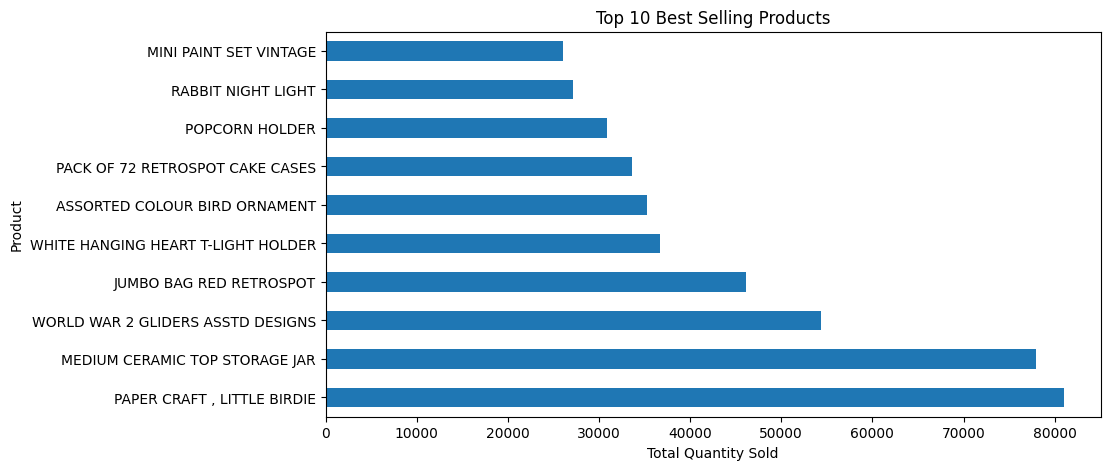

In [11]:
top_products.plot(kind='barh', figsize=(10,5))

plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()

Visualisasi Produk Terlaris

Menampilkan visualisasi produk dengan jumlah penjualan tertinggi untuk mempermudah identifikasi produk paling populer.

In [12]:
top_country = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_country

Country
United Kingdom    7242608.10
Netherlands        283889.34
Eire               257013.12
Germany            205381.15
France             183801.94
Australia          138103.81
Spain               55706.56
Switzerland         52441.95
Japan               37416.37
Belgium             36927.34
Name: Revenue, dtype: float64

Top Revenue by Country

Mengidentifikasi negara dengan total revenue tertinggi berdasarkan keseluruhan transaksi.

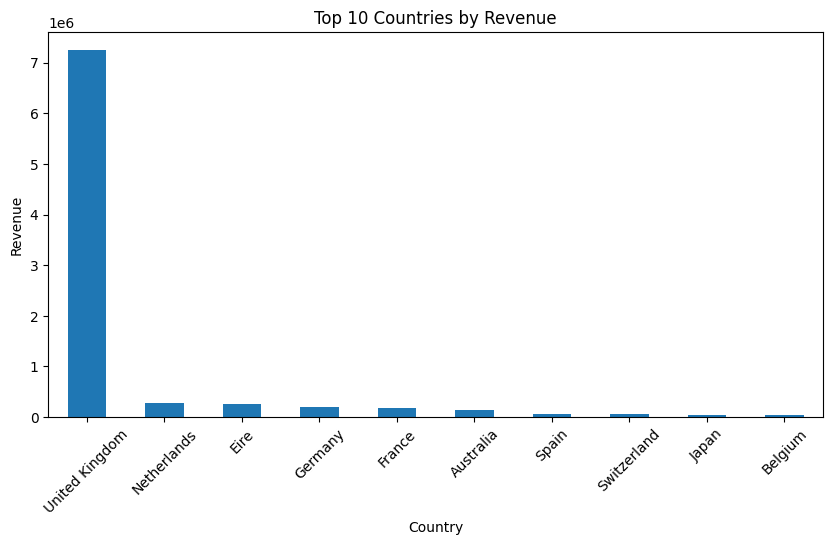

In [13]:
top_country.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Visualisasi Revenue Negara

Menampilkan visualisasi total revenue tiap negara untuk melihat kontribusi penjualan terbesar.

In [14]:
top_customer = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customer

CustomerID
14646    279138.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    136161.83
12415    124564.53
14156    116560.08
17511     91062.38
12346     77183.60
16029     72470.49
Name: Revenue, dtype: float64

Top Customer Analysis

Mengidentifikasi customer dengan total pembelian tertinggi berdasarkan revenue transaksi.

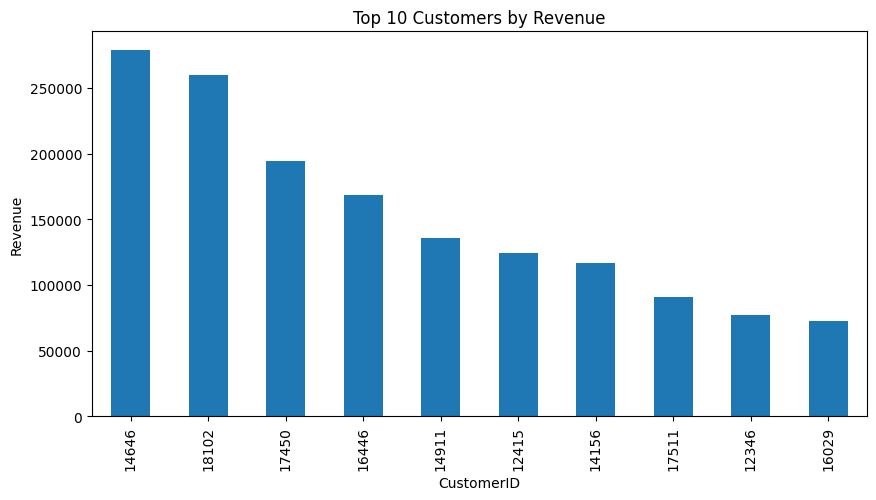

In [15]:
top_customer.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('CustomerID')
plt.ylabel('Revenue')
plt.show()

Visualisasi Top Customer

Menampilkan customer dengan kontribusi revenue terbesar untuk memahami pola pelanggan bernilai tinggi.

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_sales = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
)

monthly_sales

InvoiceDate
2010-12     564961.96
2011-01     562682.91
2011-02     442293.59
2011-03     583143.85
2011-04     454141.78
2011-05     658389.81
2011-06     653079.14
2011-07     590811.61
2011-08     634983.35
2011-09     938745.47
2011-10    1002324.10
2011-11    1136534.00
2011-12     512228.08
Freq: M, Name: Revenue, dtype: float64

Monthly Sales Trend

Menganalisis tren revenue bulanan untuk melihat pola peningkatan atau penurunan penjualan dari waktu ke waktu.

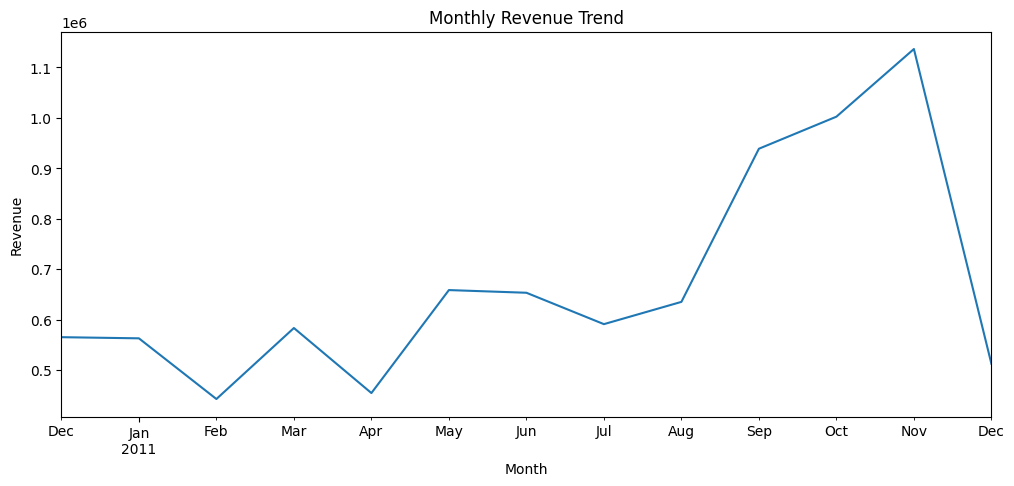

In [17]:
monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Visualisasi Tren Penjualan

Menampilkan grafik tren revenue bulanan untuk mempermudah analisis performa penjualan sepanjang periode transaksi.

In [18]:
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 8,734,319.65


Total Revenue

Menghitung total keseluruhan revenue dari seluruh transaksi untuk mengetahui total pendapatan yang dihasilkan dataset.

In [32]:
total_transaction = df['InvoiceNo'].nunique()

print(f"Total Transaction: {total_transaction:,}")

Total Transaction: 18,394


Total Transaction

Menghitung jumlah transaksi unik berdasarkan InvoiceNo untuk mengetahui total transaksi yang berhasil tercatat.

In [33]:
total_customer = df['CustomerID'].nunique()

print(f"Total Customer: {total_customer:,}")

Total Customer: 4,330


Total Customer

Menghitung jumlah customer unik untuk mengetahui total pelanggan yang melakukan transaksi.

In [34]:
print("Top Country:", top_country.idxmax())
print("Top Product:", top_products.idxmax())
print("Top Customer:", top_customer.idxmax())

Top Country: United Kingdom
Top Product: PAPER CRAFT , LITTLE BIRDIE
Top Customer: 14646


Insight Summary

Menampilkan ringkasan insight utama berupa negara dengan revenue tertinggi, produk paling laku, dan customer dengan total pembelian terbesar.

In [35]:
correlation = df[['Quantity', 'UnitPrice', 'Revenue']].corr()

correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.019931,0.916927
UnitPrice,-0.019931,1.000000,0.068318
Revenue,0.916927,0.068318,1.000000


Correlation Analysis

Menganalisis hubungan antar variabel numerik seperti Quantity, UnitPrice, dan Revenue untuk memahami keterkaitan antar data.

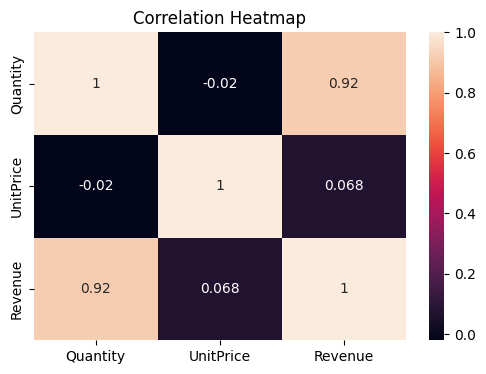

In [36]:
plt.figure(figsize=(6,4))

sns.heatmap(correlation, annot=True)

plt.title('Correlation Heatmap')
plt.show()

Correlation Heatmap

Menampilkan visualisasi korelasi antar variabel numerik untuk mempermudah interpretasi hubungan antar data.

Final Insight

Hasil Exploratory Data Analysis (EDA) menunjukkan bahwa dataset memiliki pola transaksi yang cukup konsisten dengan beberapa produk, negara, dan customer yang memberikan kontribusi revenue terbesar. Dataset yang telah melalui proses cleaning dan analisis kini siap digunakan untuk tahap visualisasi dashboard maupun pengembangan analisis lanjutan.